In [13]:
import pandas as pd
import bambi as bmb
import arviz as az
import arviz_plots as azp

df = pd.read_csv('/Users/fiodarzianiutsich/Desktop/projekt/data_cleaning/red_spruce_2022.csv')
df.columns

Index(['inventory_year', 'survey_unit', 'county', 'plot_number', 'tree_number',
       'diameter', 'height', 'SPCD', 'log_height', 'log_diameter'],
      dtype='str')

Here we define our advanced hierarchical model. We account for the macroclimate (the county level) by allowing both the baseline height (intercept) and the growth rate (slope) to vary.


In [14]:
model_formula = "log_height ~ log_diameter + (log_diameter | county)"

model = bmb.Model(model_formula, df)

In [15]:
results = model.fit(draws=2000, tune=2000, target_accept=0.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, log_diameter, 1|county_sigma, 1|county_offset, log_diameter|county_sigma, log_diameter|county_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 18 seconds.


In [16]:
az.summary(results, var_names=['Intercept', 'log_diameter', 'sigma', '1|county_sigma', 'log_diameter|county_sigma'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.172,0.059,0.059,0.281,0.001,0.001,8097.0,5578.0,1.0
log_diameter,0.791,0.022,0.748,0.830,0.000,0.000,7035.0,5557.0,1.0
sigma,0.205,0.008,0.190,0.220,0.000,0.000,9885.0,5813.0,1.0
1|county_sigma,0.083,0.044,0.000,0.154,0.001,0.001,1931.0,2075.0,1.0
log_diameter|county_sigma,0.033,0.017,0.000,0.061,0.000,0.000,2094.0,1977.0,1.0


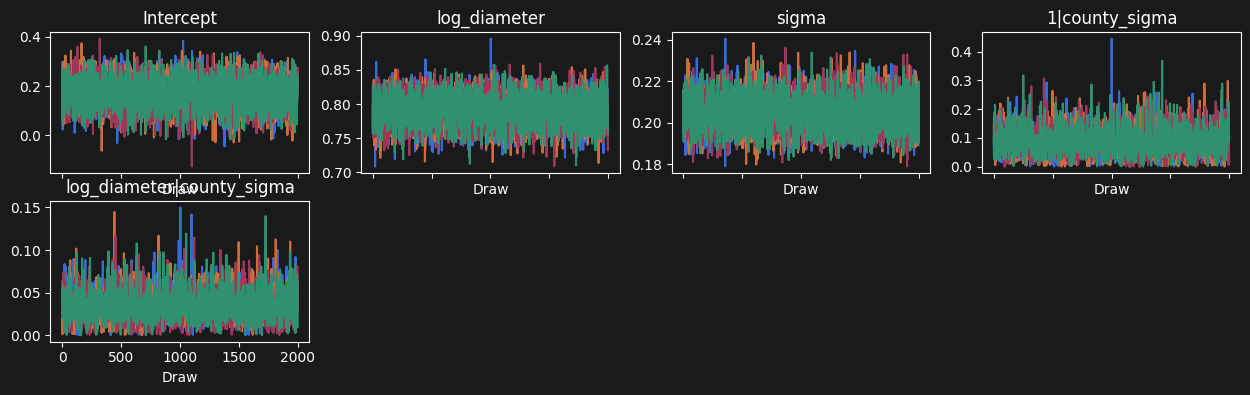

In [17]:
azp.plot_trace(results, var_names=['Intercept', 'log_diameter', 'sigma', '1|county_sigma', 'log_diameter|county_sigma'])

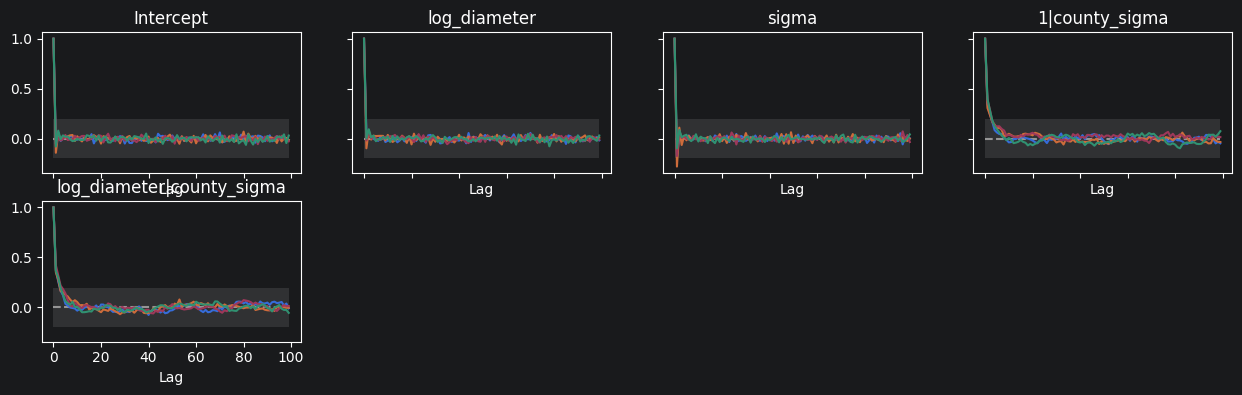

In [18]:
azp.plot_autocorr(results, var_names=['Intercept', 'log_diameter', 'sigma', '1|county_sigma', 'log_diameter|county_sigma'])

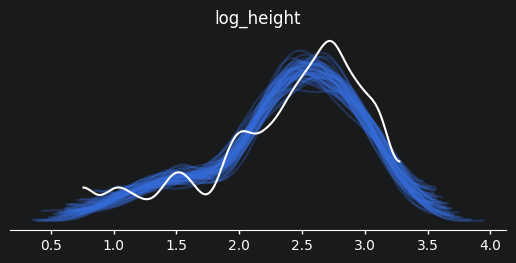

In [19]:
model.predict(results, kind="response")
azp.plot_ppc_dist(results)

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

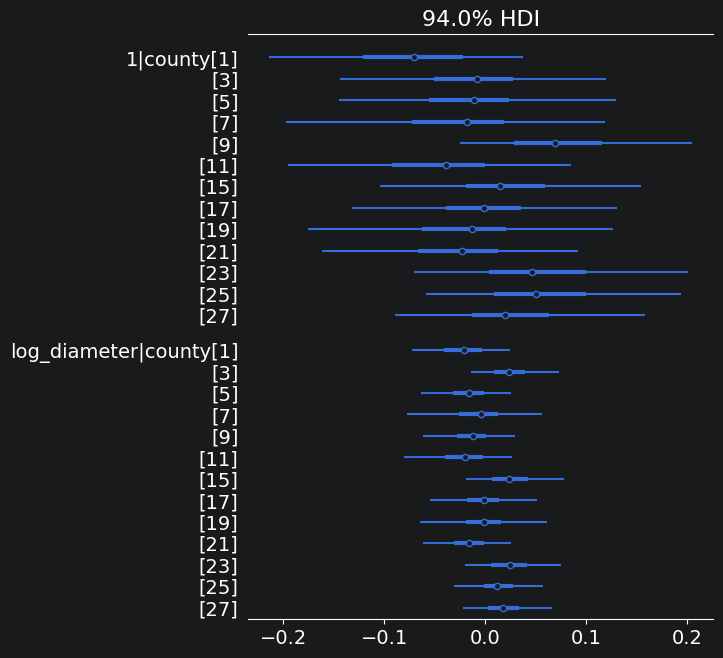

In [22]:
az.plot_forest(results, var_names=["1|county", "log_diameter|county"], combined = True)